# Arizona Occupational Migration Context
Final Jupyter Notebook for the CFA / Walmart workforce alignment analysis.

**Start here:** set `COMPUTER = "P"` for personal or `"W"` for work, then run all cells.

In [1]:
# Arizona Occupational Migration Context — FINAL
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [2]:
# 1. COMPUTER / FILES
COMPUTER = "W"  # P=personal, W=work
def paths(c):
    if str(c).upper() in {"P","PERSONAL","2"}:
        return Path(r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"), "PERSONAL"
    if str(c).upper() in {"W","WORK","1"}:
        return Path(r"C:\Users\301533\Documents\Walmart\IPEDS\Files"), "WORK"
    raise ValueError("Use P or W.")
BASE, LABEL = paths(COMPUTER)
ACS_FILE = BASE / "usa_00004.csv"
MASTER_FILE = BASE / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
OUTPUT_FILE = BASE / "Arizona_Occupational_Migration_OCC2010.xlsx"
print("Computer:", LABEL, "\nACS:", ACS_FILE, ACS_FILE.exists(), "\nMaster:", MASTER_FILE, MASTER_FILE.exists())
if not ACS_FILE.exists(): raise FileNotFoundError(ACS_FILE)
if not MASTER_FILE.exists(): raise FileNotFoundError(MASTER_FILE)

Computer: WORK 
ACS: C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00004.csv True 
Master: C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx True


In [3]:
# 2. SELECT 5-STAR HEALTHCARE + MANUFACTURING OCCUPATIONS
master = pd.read_excel(MASTER_FILE, sheet_name="Master_Matched_Data")
def clean_soc(x):
    if pd.isna(x): return np.nan
    d = "".join(ch for ch in str(x) if ch.isdigit())
    return f"{d[:2]}-{d[2:6]}" if len(d)>=6 else str(x).strip()
master["soc"] = master["SOC_Code"].apply(clean_soc)
sel = master[
    pd.to_numeric(master["Sum of Occupation Rating by Ed Lvl1"], errors="coerce").eq(5)
    & master["Industry"].isin(["Healthcare","Manufacturing"])
].copy()
occ = sel[["soc","Job Title","Industry","Employment ('25)","Education Level",
           "Projected Ann. Job Openings ('25 - '27)","Average Wage ('25)"]].drop_duplicates("soc")
occ = occ.rename(columns={"Job Title":"job_title","Industry":"sector",
    "Employment ('25)":"master_employment_2025","Education Level":"education_level",
    "Projected Ann. Job Openings ('25 - '27)":"projected_annual_openings_2025_27",
    "Average Wage ('25)":"average_wage_2025"})
print("\nSelected occupations:", occ["soc"].nunique())
print(occ.groupby("sector")["soc"].nunique())


Selected occupations: 36
sector
Healthcare       25
Manufacturing    11
Name: soc, dtype: int64


In [4]:
# 3. SOC -> OCC2010
M = {
"21-1094":(2025,"Community and social service specialists, all other","BROADER"),
"29-1021":(3010,"Dentists","BROADER"),
"29-1041":(3040,"Optometrists","DIRECT / HARMONIZED"),
"29-1071":(3110,"Physician assistants","DIRECT / HARMONIZED"),
"29-1122":(3150,"Occupational therapists","DIRECT / HARMONIZED"),
"29-1123":(3160,"Physical therapists","DIRECT / HARMONIZED"),
"29-1126":(3220,"Respiratory therapists","DIRECT / HARMONIZED"),
"29-1127":(3230,"Speech-language pathologists","DIRECT / HARMONIZED"),
"29-1141":(3255,"Registered nurses","DIRECT / HARMONIZED"),
"29-1151":(3256,"Nurse anesthetists","DIRECT / HARMONIZED"),
"29-1171":(3258,"Nurse practitioners","DIRECT / HARMONIZED"),
"29-1215":(3060,"Physicians and surgeons","BROADER"),
"29-1292":(3310,"Dental hygienists","DIRECT / HARMONIZED"),
"29-2032":(3320,"Diagnostic related technologists and technicians","BROADER"),
"29-2034":(3320,"Diagnostic related technologists and technicians","BROADER"),
"29-2035":(3320,"Diagnostic related technologists and technicians","BROADER"),
"29-2055":(3420,"Health practitioner support technologists and technicians","BROADER"),
"29-2061":(3500,"Licensed practical and licensed vocational nurses","DIRECT / HARMONIZED"),
"31-2021":(3620,"Physical therapist assistants and aides","BROADER"),
"31-9093":(3655,"Miscellaneous healthcare support occupations","BROADER"),
"31-9099":(3655,"Miscellaneous healthcare support occupations","BROADER"),
"35-2012":(4020,"Cooks","BROADER"),
"35-3041":(4120,"Food servers, nonrestaurant","DIRECT / HARMONIZED"),
"43-6013":(5700,"Secretaries and administrative assistants","DIRECT / HARMONIZED"),
"53-2012":(9030,"Aircraft pilots and flight engineers","BROADER"),
"13-1081":(700,"Logisticians","DIRECT / HARMONIZED"),
"17-2061":(1400,"Computer hardware engineers","DIRECT / HARMONIZED"),
"17-2071":(1410,"Electrical and electronics engineers","BROADER / SHARED"),
"17-2072":(1410,"Electrical and electronics engineers","BROADER / SHARED"),
"17-2112":(1430,"Industrial engineers, including health and safety","BROADER"),
"17-2141":(1460,"Mechanical engineers","DIRECT / HARMONIZED"),
"49-9041":(7330,"Industrial and refractory machinery mechanics","BROADER"),
"51-1011":(7700,"First-line supervisors of production and operating workers","DIRECT / HARMONIZED"),
"51-4041":(8030,"Machinists","DIRECT / HARMONIZED"),
"51-4121":(8140,"Welding, soldering, and brazing workers","BROADER"),
"51-9141":(8840,"Semiconductor processing technicians","DIRECT / HARMONIZED")}
mp = pd.DataFrame([{"soc":s,"OCC2010":v[0],"acs_group":v[1],"mapping_quality":v[2]} for s,v in M.items()])
omap = occ.merge(mp,on="soc",how="left")
if omap["OCC2010"].isna().any():
    print(omap.loc[omap["OCC2010"].isna(),["soc","job_title"]]); raise ValueError("Missing mapping.")
omap["OCC2010"]=omap["OCC2010"].astype(int)
cnt=omap.groupby("OCC2010")["soc"].nunique().rename("selected_socs_in_acs_group").reset_index()
omap=omap.merge(cnt,on="OCC2010",how="left")
omap["shared_acs_group"]=omap["selected_socs_in_acs_group"].gt(1)

In [5]:
# 4. ACS
YEARS=[2014,2019,2024]; AZ=4
STATE_DC={1,2,4,5,6,8,9,10,11,12,13,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,44,45,46,47,48,49,50,51,53,54,55,56}
cols=["YEAR","SAMPLE","STATEFIP","PERWT","EMPSTAT","OCC2010","OCCSOC","MIGRATE1","MIGRATE1D","MIGPLAC1"]
missing=[c for c in cols if c not in pd.read_csv(ACS_FILE,nrows=0).columns]
if missing: raise ValueError(f"Missing ACS columns: {missing}")
relevant=set(omap["OCC2010"])
parts=[]
for ch in pd.read_csv(ACS_FILE,usecols=cols,chunksize=500_000,low_memory=False):
    for c in ["YEAR","STATEFIP","PERWT","EMPSTAT","OCC2010","MIGPLAC1"]:
        ch[c]=pd.to_numeric(ch[c],errors="coerce")
    ch=ch[ch["YEAR"].isin(YEARS)&ch["EMPSTAT"].eq(1)&ch["OCC2010"].isin(relevant)]
    ch=ch[ch["STATEFIP"].eq(AZ)|ch["MIGPLAC1"].eq(AZ)]
    if len(ch): parts.append(ch)
acs=pd.concat(parts,ignore_index=True)
print("\nRetained ACS records:",f"{len(acs):,}")


Retained ACS records: 45,691


In [6]:
# 5. DEFINITIONS
acs["current_az"]=acs["STATEFIP"].eq(AZ)
acs["inflow"]=acs["STATEFIP"].eq(AZ)&acs["MIGPLAC1"].isin(STATE_DC-{AZ})
# Context only: current occupation is known, prior occupation is not.
acs["current_elsewhere_prior_AZ"]=acs["STATEFIP"].ne(AZ)&acs["MIGPLAC1"].eq(AZ)

In [7]:
# 6. AGGREGATE UNIQUE ACS GROUPS
rows=[]
for (yr,o),g in acs.groupby(["YEAR","OCC2010"]):
    cur=g.loc[g.current_az,"PERWT"].sum()
    infl=g.loc[g.inflow,"PERWT"].sum()
    outctx=g.loc[g.current_elsewhere_prior_AZ,"PERWT"].sum()
    cn=int(g.current_az.sum()); inn=int(g.inflow.sum()); outn=int(g.current_elsewhere_prior_AZ.sum())
    pct=np.nan if cur==0 else 100*infl/cur
    if cn==0: rel="NO ACS MATCH"
    elif min(inn,outn)<20: rel="LOW - use caution"
    elif min(inn,outn)<50: rel="MODERATE"
    else: rel="STRONGER"
    rows.append({"year":int(yr),"OCC2010":int(o),"AZ_current_employed":cur,
        "AZ_interstate_inflow":infl,"inflow_pct_current_AZ":pct,
        "current_elsewhere_prior_AZ":outctx,
        "net_migration_context_only":infl-outctx,
        "current_sample_n":cn,"inflow_sample_n":inn,
        "elsewhere_prior_AZ_sample_n":outn,"reliability":rel})
res=pd.DataFrame(rows)
groups=omap[["OCC2010","acs_group","mapping_quality"]].drop_duplicates("OCC2010")
grid=pd.MultiIndex.from_product([YEARS,groups.OCC2010],names=["year","OCC2010"]).to_frame(index=False)
gres=grid.merge(groups,on="OCC2010",how="left").merge(res,on=["year","OCC2010"],how="left")
for c in ["AZ_current_employed","AZ_interstate_inflow","current_elsewhere_prior_AZ","net_migration_context_only",
          "current_sample_n","inflow_sample_n","elsewhere_prior_AZ_sample_n"]:
    gres[c]=gres[c].fillna(0)
gres.loc[gres.AZ_current_employed.eq(0),"reliability"]="NO ACS MATCH"

In [8]:
# 7. DETAILED SOC TABLE — repeated shared-group values must NOT be summed
detail=omap.merge(gres.drop(columns=["acs_group","mapping_quality"]),on="OCC2010",how="left")
detail=detail.sort_values(["year","sector","soc"])

In [9]:
# 8. 2024 PRESENTATION TABLE
p24=detail[detail.year.eq(2024)].copy()
p24["recommended_for_main_figure"]=(
    p24["mapping_quality"].eq("DIRECT / HARMONIZED")
    & p24["inflow_sample_n"].ge(20)
    & p24["AZ_current_employed"].gt(0))
p24=p24.sort_values(["inflow_pct_current_AZ","AZ_interstate_inflow"],ascending=[False,False])

In [10]:
# 9. RN QA
rn=detail[detail.soc.eq("29-1141")][["year","AZ_current_employed","AZ_interstate_inflow",
"inflow_pct_current_AZ","current_elsewhere_prior_AZ","net_migration_context_only",
"inflow_sample_n","elsewhere_prior_AZ_sample_n","reliability"]].sort_values("year")
print("\nREGISTERED NURSE QA")
print(rn.to_string(index=False))


REGISTERED NURSE QA
 year  AZ_current_employed  AZ_interstate_inflow  inflow_pct_current_AZ  current_elsewhere_prior_AZ  net_migration_context_only  inflow_sample_n  elsewhere_prior_AZ_sample_n reliability
 2014              52238.0                2084.0               3.989433                      1570.0                       514.0            100.0                         67.0    STRONGER
 2019              60200.0                2465.0               4.094684                      1689.0                       776.0            119.0                         67.0    STRONGER
 2024              69258.0                3200.0               4.620405                      2475.0                       725.0            119.0                        107.0    STRONGER


In [11]:
# 10. METHODS
notes=pd.DataFrame({"topic":["Purpose","Geography","Primary measure","Out-movement limitation",
"IPEDS relationship","Shared groups","Reliability","Reporting"],
"note":[
"Arizona statewide migration context for the Maricopa County education/employment alignment analysis.",
"These are Arizona statewide estimates, not Maricopa County migration estimates.",
"Interstate inflow = current Arizona resident, lived in another U.S. state/DC one year earlier, currently employed in the occupation.",
"ACS observes current occupation, not prior occupation. current_elsewhere_prior_AZ is context only and is not confirmed occupation-specific outflow.",
"Do not add ACS inflow to IPEDS completions; the measures represent different concepts.",
"Detailed SOCs sharing one OCC2010 group repeat the same ACS estimate and must not be summed.",
"LOW/MODERATE/STRONGER is descriptive sample-size QA only, not a Census MOE/significance test.",
"For main figures, prioritize direct/harmonized estimates with adequate sample size; explicitly label broader Census occupation groups."
]})

In [12]:
# 11. SAVE
with pd.ExcelWriter(OUTPUT_FILE,engine="openpyxl") as w:
    detail.to_excel(w,sheet_name="Detailed_SOC",index=False)
    gres.to_excel(w,sheet_name="ACS_Group_Unique",index=False)
    p24.to_excel(w,sheet_name="2024_Presentation",index=False)
    omap.to_excel(w,sheet_name="SOC_OCC2010_Mapping",index=False)
    rn.to_excel(w,sheet_name="RN_QA",index=False)
    notes.to_excel(w,sheet_name="Methods_ReadMe",index=False)

print("\nDONE\nSaved to:",OUTPUT_FILE)
print("\nUse inflow as workforce context; do not add it to IPEDS completions.")


DONE
Saved to: C:\Users\301533\Documents\Walmart\IPEDS\Files\Arizona_Occupational_Migration_OCC2010.xlsx

Use inflow as workforce context; do not add it to IPEDS completions.


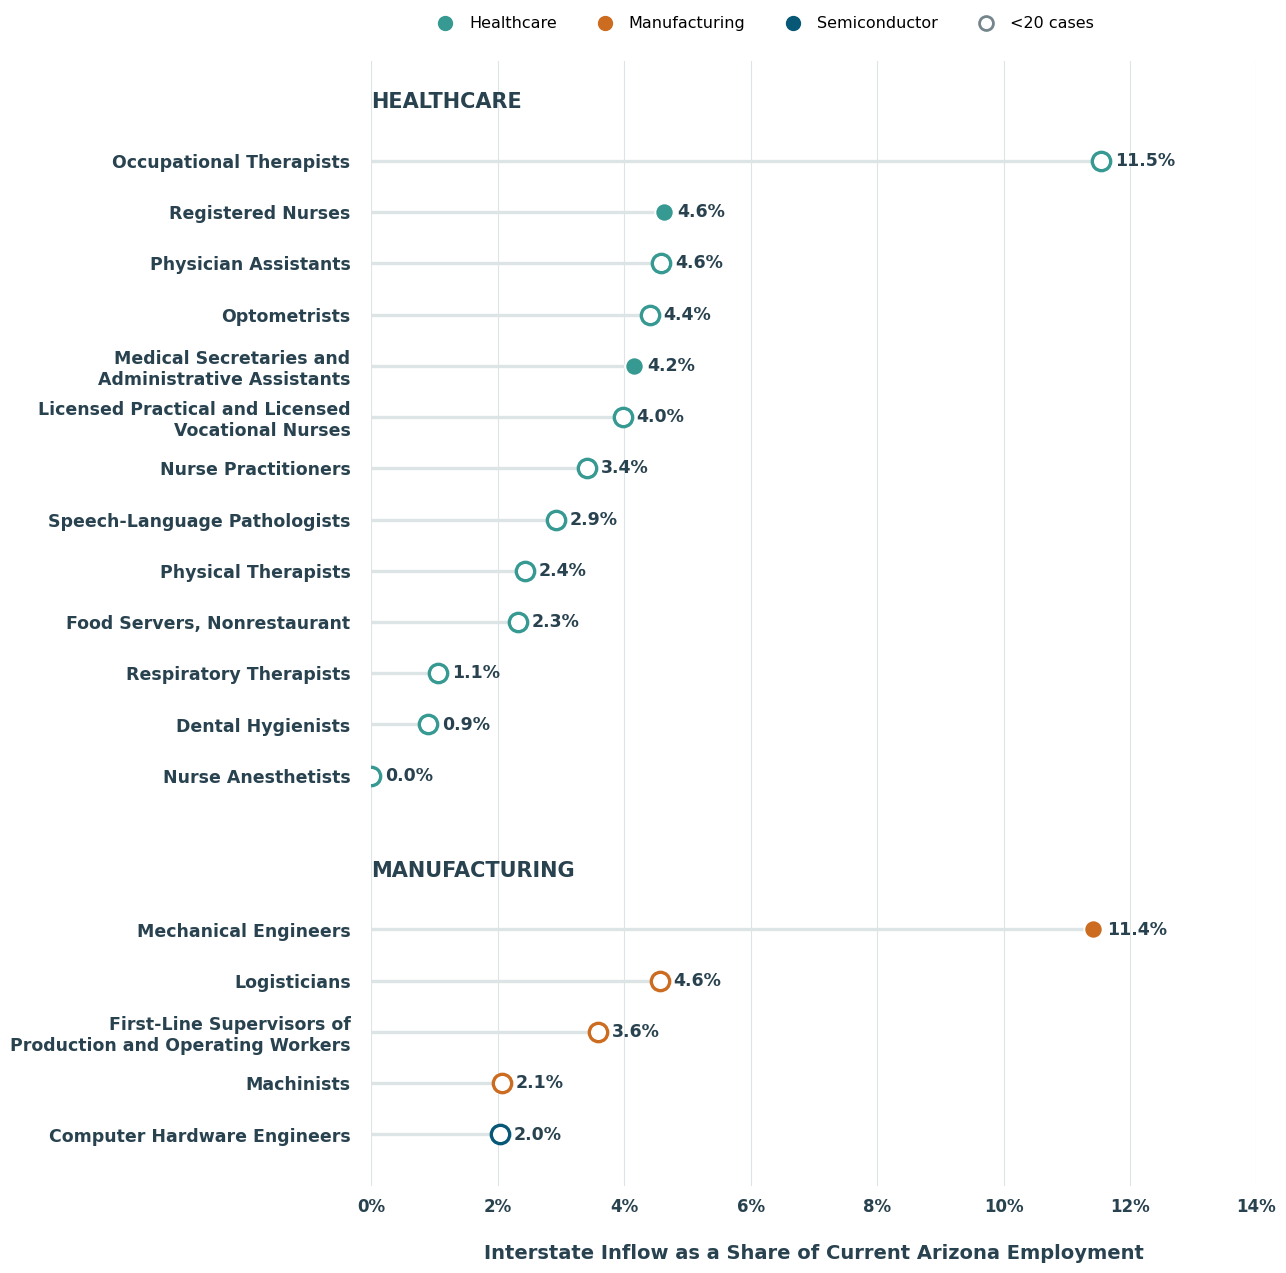

Saved: C:\Users\301533\Documents\Walmart\IPEDS\Files\Arizona_Migration_Clean_Final.png

Number of occupations displayed: 18

Healthcare: 13
Manufacturing: 5

Semiconductor occupations displayed:
    soc                   job_title  inflow_pct_current_AZ  inflow_sample_n
17-2061 Computer Hardware Engineers               2.036022                2


In [13]:
# ============================================================
# CLEAN MIGRATION FIGURE — ONE CONTINUOUS LIST
# Healthcare first, then Manufacturing
# Semiconductor occupations shown in blue
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import textwrap


# ============================================================
# 1. LOAD DATA
# ============================================================

MIGRATION_FILE = BASE / "Arizona_Occupational_Migration_OCC2010.xlsx"

df = pd.read_excel(
    MIGRATION_FILE,
    sheet_name="2024_Presentation"
)

for col in [
    "inflow_pct_current_AZ",
    "inflow_sample_n",
    "AZ_current_employed"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 2. DEFINE SEMICONDUCTOR OCCUPATIONS
# ============================================================

SEMICONDUCTOR_SOCS = {
    "17-2061",   # Computer Hardware Engineers
    "17-2112",   # Industrial Engineers
    "51-9141",   # Semiconductor Processing Technicians
}

df["visual_sector"] = df["sector"]

df.loc[
    df["soc"].isin(SEMICONDUCTOR_SOCS),
    "visual_sector"
] = "Semiconductor"


# ============================================================
# 3. FILTER
# ============================================================
# Keep direct/harmonized occupation estimates.
#
# Hollow dots = fewer than 20 observed inflow cases.
# We DO NOT remove low-sample occupations.

plot = df[
    df["mapping_quality"].eq("DIRECT / HARMONIZED")
    & df["AZ_current_employed"].gt(0)
    & df["inflow_pct_current_AZ"].notna()
].copy()

plot["adequate_sample"] = (
    plot["inflow_sample_n"] >= 20
)


# ============================================================
# 4. SPLIT + SORT
# ============================================================
# Highest migration share at TOP of each section.

health = (
    plot[
        plot["sector"].eq("Healthcare")
    ]
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
    .reset_index(drop=True)
)

manufacturing = (
    plot[
        plot["sector"].eq("Manufacturing")
    ]
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 5. LABEL WRAPPING
# ============================================================

def wrap_label(text, width=34):

    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width,
            break_long_words=False
        )
    )

health["display_label"] = (
    health["job_title"]
    .apply(wrap_label)
)

manufacturing["display_label"] = (
    manufacturing["job_title"]
    .apply(wrap_label)
)


# ============================================================
# 6. COLORS
# ============================================================

HEALTHCARE = "#369992"

MANUFACTURING = "#CC6C20"

SEMICONDUCTOR = "#075877"

TEXT = "#29424F"

GRAY = "#75858C"

GRID = "#DDE4E6"

WHITE = "#FFFFFF"


COLOR_MAP = {
    "Healthcare": HEALTHCARE,
    "Manufacturing": MANUFACTURING,
    "Semiconductor": SEMICONDUCTOR
}


# ============================================================
# 7. BUILD ONE CONTINUOUS Y-AXIS
# ============================================================
#
# Layout:
#
# HEALTHCARE
# occupation
# occupation
# occupation
#
# MANUFACTURING
# occupation
# occupation
# occupation
#
# This avoids two separate panels and the huge blank gap.


rows = []

y_position = 0


# --------------------------
# Healthcare
# --------------------------

health_header_y = y_position

y_position += 1.15


for _, row in health.iterrows():

    temp = row.to_dict()

    temp["y"] = y_position

    rows.append(temp)

    y_position += 1


# Small clean gap between groups

y_position += 0.85


# --------------------------
# Manufacturing
# --------------------------

manufacturing_header_y = y_position

y_position += 1.15


for _, row in manufacturing.iterrows():

    temp = row.to_dict()

    temp["y"] = y_position

    rows.append(temp)

    y_position += 1


chart = pd.DataFrame(rows)


# ============================================================
# 8. FIGURE SIZE
# ============================================================

# Automatically becomes taller when more occupations are present.

FIG_HEIGHT = max(
    10,
    len(chart) * 0.56 + 3
)

fig, ax = plt.subplots(
    figsize=(15, FIG_HEIGHT)
)

fig.patch.set_facecolor(WHITE)

ax.set_facecolor(WHITE)


# ============================================================
# 9. X AXIS LIMIT
# ============================================================

max_value = chart["inflow_pct_current_AZ"].max()

XMAX = max(
    6,
    np.ceil(
        (max_value + 1.5) / 2
    ) * 2
)

ax.set_xlim(
    0,
    XMAX
)


# ============================================================
# 10. CONNECTOR LINES
# ============================================================

for _, row in chart.iterrows():

    ax.hlines(
        y=row["y"],
        xmin=0,
        xmax=row["inflow_pct_current_AZ"],
        color=GRID,
        linewidth=2.4,
        zorder=1
    )


# ============================================================
# 11. DOTS + VALUES
# ============================================================

for _, row in chart.iterrows():

    color = COLOR_MAP[
        row["visual_sector"]
    ]

    # ----------------------------------------
    # Filled marker
    # ----------------------------------------

    if row["adequate_sample"]:

        ax.scatter(
            row["inflow_pct_current_AZ"],
            row["y"],
            s=175,
            color=color,
            edgecolor=WHITE,
            linewidth=1.4,
            zorder=3
        )

    # ----------------------------------------
    # Hollow marker
    # ----------------------------------------

    else:

        ax.scatter(
            row["inflow_pct_current_AZ"],
            row["y"],
            s=175,
            facecolor=WHITE,
            edgecolor=color,
            linewidth=2.4,
            zorder=3
        )


    # ----------------------------------------
    # Percentage
    # ----------------------------------------

    ax.annotate(
        f'{row["inflow_pct_current_AZ"]:.1f}%',
        xy=(
            row["inflow_pct_current_AZ"],
            row["y"]
        ),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=12.5,
        fontweight="bold",
        color=TEXT
    )


# ============================================================
# 12. OCCUPATION LABELS
# ============================================================

ax.set_yticks(
    chart["y"]
)

ax.set_yticklabels(
    chart["display_label"],
    fontsize=12.5,
    fontweight="bold",
    color=TEXT
)

ax.tick_params(
    axis="y",
    length=0,
    pad=15
)


# ============================================================
# 13. SECTION HEADERS
# ============================================================

# Headers are positioned ABOVE their occupation lists,
# rather than in the legend/title area.

ax.text(
    0,
    health_header_y,
    "HEALTHCARE",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)

ax.text(
    0,
    manufacturing_header_y,
    "MANUFACTURING",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)


# ============================================================
# 14. MAKE TOP ACTUALLY APPEAR AT TOP
# ============================================================

ax.set_ylim(
    y_position,
    -0.8
)


# ============================================================
# 15. X AXIS
# ============================================================

ax.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=0
    )
)

ax.tick_params(
    axis="x",
    labelsize=12,
    colors=TEXT,
    length=0,
    pad=9
)


# Bold x tick labels

for label in ax.get_xticklabels():

    label.set_fontweight(
        "bold"
    )


ax.set_xlabel(
    "Interstate Inflow as a Share of Current Arizona Employment",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=20
)


# ============================================================
# 16. GRID
# ============================================================

ax.grid(
    axis="x",
    color=GRID,
    linewidth=0.8
)

ax.grid(
    axis="y",
    visible=False
)


# ============================================================
# 17. REMOVE ALL BORDERS
# ============================================================

for spine in [
    "top",
    "right",
    "left",
    "bottom"
]:

    ax.spines[spine].set_visible(
        False
    )


# ============================================================
# 18. LEGEND
# ============================================================
#
# Put legend ABOVE chart with its own dedicated space.
# It will no longer overlap Healthcare.


legend_items = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=HEALTHCARE,
        markeredgecolor=HEALTHCARE,
        markersize=10,
        label="Healthcare"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=MANUFACTURING,
        markeredgecolor=MANUFACTURING,
        markersize=10,
        label="Manufacturing"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=SEMICONDUCTOR,
        markeredgecolor=SEMICONDUCTOR,
        markersize=10,
        label="Semiconductor"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=WHITE,
        markeredgecolor=GRAY,
        markeredgewidth=2,
        markersize=10,
        label="<20 cases"
    )
]


fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.60, 0.985),
    frameon=False,
    ncol=4,
    fontsize=11.5,
    handletextpad=0.5,
    columnspacing=2
)


# ============================================================
# 19. LAYOUT
# ============================================================

# Lots of room on left for long occupation names.
# Dedicated blank area at top for legend.

plt.subplots_adjust(
    left=0.34,
    right=0.93,
    top=0.94,
    bottom=0.08
)


# ============================================================
# 20. SAVE
# ============================================================

OUTPUT_PNG = (
    BASE
    / "Arizona_Migration_Clean_Final.png"
)

plt.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE
)

plt.show()

print(
    "Saved:",
    OUTPUT_PNG
)


# ============================================================
# 21. QA
# ============================================================

print(
    "\nNumber of occupations displayed:",
    len(chart)
)

print(
    "\nHealthcare:",
    len(health)
)

print(
    "Manufacturing:",
    len(manufacturing)
)

print(
    "\nSemiconductor occupations displayed:"
)

print(
    manufacturing.loc[
        manufacturing[
            "visual_sector"
        ].eq("Semiconductor"),
        [
            "soc",
            "job_title",
            "inflow_pct_current_AZ",
            "inflow_sample_n"
        ]
    ].to_string(
        index=False
    )
)

In [15]:
# ============================================================
# CHECK OUR 36 OCCUPATIONS AGAINST 2024 ACS OCCSOC
# ============================================================
#
# PURPOSE:
# Before doing any more migration analysis, determine how well
# our selected detailed SOC occupations match the SOC-based
# occupation variable already contained in the IPUMS ACS file.
#
# OUTPUT:
#   ACS_OCCSOC_MATCH_QA.xlsx
#
# This DOES NOT change the migration analysis yet.
# It is just a diagnostic.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


# ============================================================
# 1. CHOOSE COMPUTER
# ============================================================

# P = personal
# W = work

COMPUTER = "W"


def get_paths(computer):

    key = str(computer).strip().upper()

    if key in {"P", "PERSONAL", "HOME", "2"}:

        base = Path(
            r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
        )

    elif key in {"W", "WORK", "1"}:

        base = Path(
            r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        )

    else:

        raise ValueError(
            "COMPUTER must be P/PERSONAL or W/WORK"
        )

    return base


BASE = get_paths(COMPUTER)

MASTER_FILE = (
    BASE / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
)

ACS_FILE = (
    BASE / "usa_00004.csv"
)

OUTPUT_FILE = (
    BASE / "ACS_OCCSOC_MATCH_QA.xlsx"
)


print("BASE:")
print(BASE)

print("\nMASTER:")
print(MASTER_FILE)

print("\nACS:")
print(ACS_FILE)


# ============================================================
# 2. HELPER — CLEAN SOC CODES
# ============================================================

def clean_soc(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    # Remove punctuation/spaces.
    # Example:
    # 17-2061 -> 172061
    # 29-1141 -> 291141

    value = re.sub(
        r"[^0-9A-Z]",
        "",
        value
    )

    return value


# ============================================================
# 3. LOAD MASTER OCCUPATION FILE
# ============================================================

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)

print(
    "\nMaster rows:",
    len(master)
)


# ============================================================
# 4. IDENTIFY OUR FIVE-STAR OCCUPATIONS
# ============================================================

master["rating"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)

selected = master[
    master["rating"].eq(5)
    & master["Industry"].isin(
        [
            "Healthcare",
            "Manufacturing"
        ]
    )
].copy()


# One row per SOC.
# The master contains multiple CIP rows for some occupations.

selected = (
    selected[
        [
            "SOC_Code",
            "SOC_Title",
            "Industry",
            "Employment ('25)"
        ]
    ]
    .drop_duplicates(
        subset=["SOC_Code"]
    )
    .copy()
)


selected["SOC_clean"] = (
    selected["SOC_Code"]
    .apply(clean_soc)
)


# ============================================================
# 5. SEMICONDUCTOR FLAG
# ============================================================

SEMICONDUCTOR_SOCS = {
    "172061",   # Computer Hardware Engineers
    "172112",   # Industrial Engineers
    "519141",   # Semiconductor Processing Technicians
}

selected["Semiconductor"] = np.where(
    selected["SOC_clean"].isin(
        SEMICONDUCTOR_SOCS
    ),
    "Yes",
    "No"
)


print(
    "\nSelected occupations:",
    len(selected)
)

print(
    "\nBy industry:"
)

print(
    selected["Industry"]
    .value_counts()
)


# ============================================================
# 6. READ ONLY THE ACS COLUMNS WE NEED
# ============================================================

# We only need OCCSOC and a few QA fields.
# Reading only these columns is much faster than loading
# the entire ACS file.

header = pd.read_csv(
    ACS_FILE,
    nrows=0
)

available_columns = (
    header.columns
    .tolist()
)

print(
    "\nACS columns available:"
)

print(
    available_columns
)


required = [
    "OCCSOC",
    "STATEFIP",
    "EMPSTAT",
    "PERWT"
]

missing = [
    c for c in required
    if c not in available_columns
]

if missing:

    raise ValueError(
        f"""
STOP — these columns are missing from the ACS file:

{missing}

Available columns are:

{available_columns}
"""
    )


# ============================================================
# 7. GET UNIQUE OCCSOC VALUES FROM ACS
# ============================================================

occ_counts = {}


for chunk in pd.read_csv(
    ACS_FILE,
    usecols=required,
    chunksize=500_000,
    low_memory=False
):

    # --------------------------------------------------------
    # Focus QA on currently employed Arizona workers
    # --------------------------------------------------------

    chunk["STATEFIP"] = pd.to_numeric(
        chunk["STATEFIP"],
        errors="coerce"
    )

    chunk["EMPSTAT"] = pd.to_numeric(
        chunk["EMPSTAT"],
        errors="coerce"
    )

    az = chunk[
        chunk["STATEFIP"].eq(4)
        & chunk["EMPSTAT"].eq(1)
    ].copy()


    # --------------------------------------------------------
    # Clean OCCSOC
    # --------------------------------------------------------

    az["OCCSOC_clean"] = (
        az["OCCSOC"]
        .apply(clean_soc)
    )


    counts = (
        az["OCCSOC_clean"]
        .value_counts(
            dropna=True
        )
    )


    for code, n in counts.items():

        occ_counts[code] = (
            occ_counts.get(code, 0)
            + int(n)
        )


acs_soc = pd.DataFrame(
    {
        "OCCSOC_clean": list(
            occ_counts.keys()
        ),

        "ACS_AZ_sample_n": list(
            occ_counts.values()
        )
    }
)


print(
    "\nUnique OCCSOC values among employed AZ workers:",
    len(acs_soc)
)


# ============================================================
# 8. EXACT MATCH
# ============================================================

result = selected.merge(
    acs_soc,
    left_on="SOC_clean",
    right_on="OCCSOC_clean",
    how="left"
)


result["Exact_OCCSOC_Match"] = np.where(
    result["ACS_AZ_sample_n"].notna(),
    "YES",
    "NO"
)


# ============================================================
# 9. SEARCH FOR AGGREGATED / RELATED OCCSOC CODES
# ============================================================
#
# Some OCCSOC values contain X characters.
#
# Example concept:
#
#     29-XXXX
#
# means ACS cannot identify the detailed occupation exactly.
#
# This section looks for an OCCSOC code that shares the same
# beginning digits as our detailed SOC.


acs_codes = (
    acs_soc["OCCSOC_clean"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


def find_related_codes(soc):

    if pd.isna(soc):
        return ""

    soc = str(soc)

    matches = []

    for acs_code in acs_codes:

        code = str(acs_code)

        # ----------------------------------------------------
        # Exact
        # ----------------------------------------------------

        if code == soc:
            continue


        # ----------------------------------------------------
        # Convert X values to regex wildcard
        #
        # Example:
        # 1720XX
        # becomes
        # ^1720..$
        # ----------------------------------------------------

        if "X" in code:

            pattern = (
                "^"
                + re.escape(code)
                .replace(
                    "X",
                    "."
                )
                + "$"
            )

            if re.match(
                pattern,
                soc
            ):

                matches.append(
                    code
                )

    return "; ".join(
        sorted(
            set(matches)
        )
    )


result["Related_Aggregated_OCCSOC"] = (
    result["SOC_clean"]
    .apply(find_related_codes)
)


# ============================================================
# 10. CLASSIFY MATCH QUALITY
# ============================================================

def classify_match(row):

    if row["Exact_OCCSOC_Match"] == "YES":

        return "EXACT"

    if (
        isinstance(
            row["Related_Aggregated_OCCSOC"],
            str
        )
        and row[
            "Related_Aggregated_OCCSOC"
        ].strip() != ""
    ):

        return "AGGREGATED"

    return "NO MATCH"


result["Match_Status"] = (
    result.apply(
        classify_match,
        axis=1
    )
)


# ============================================================
# 11. CLEAN OUTPUT
# ============================================================

result = result[
    [
        "SOC_Code",
        "SOC_Title",
        "Industry",
        "Semiconductor",
        "Employment ('25)",
        "SOC_clean",
        "Exact_OCCSOC_Match",
        "ACS_AZ_sample_n",
        "Related_Aggregated_OCCSOC",
        "Match_Status"
    ]
].copy()


# Sort in useful order

industry_order = {
    "Healthcare": 1,
    "Manufacturing": 2
}

status_order = {
    "EXACT": 1,
    "AGGREGATED": 2,
    "NO MATCH": 3
}

result["_industry_order"] = (
    result["Industry"]
    .map(industry_order)
)

result["_status_order"] = (
    result["Match_Status"]
    .map(status_order)
)


result = (
    result
    .sort_values(
        [
            "_industry_order",
            "_status_order",
            "SOC_Title"
        ]
    )
    .drop(
        columns=[
            "_industry_order",
            "_status_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 12. SUMMARY
# ============================================================

summary = (
    result[
        "Match_Status"
    ]
    .value_counts()
    .rename_axis(
        "Match_Status"
    )
    .reset_index(
        name="Number_of_Occupations"
    )
)


print(
    "\n=========================================="
)

print(
    "MATCH RESULTS"
)

print(
    "=========================================="
)

print(summary.to_string(index=False))


print(
    "\n=========================================="
)

print(
    "ALL 36 OCCUPATIONS"
)

print(
    "=========================================="
)

print(
    result[
        [
            "SOC_Code",
            "SOC_Title",
            "Industry",
            "Semiconductor",
            "Match_Status",
            "Related_Aggregated_OCCSOC",
            "ACS_AZ_sample_n"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 13. SEMICONDUCTOR QA
# ============================================================

semi_qa = result[
    result["Semiconductor"].eq(
        "Yes"
    )
].copy()


print(
    "\n=========================================="
)

print(
    "SEMICONDUCTOR OCCUPATIONS"
)

print(
    "=========================================="
)

print(
    semi_qa.to_string(
        index=False
    )
)


# ============================================================
# 14. WRITE EXCEL OUTPUT
# ============================================================

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    result.to_excel(
        writer,
        sheet_name="All_36_Occupations",
        index=False
    )

    summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    semi_qa.to_excel(
        writer,
        sheet_name="Semiconductor_QA",
        index=False
    )

    acs_soc.sort_values(
        "OCCSOC_clean"
    ).to_excel(
        writer,
        sheet_name="ACS_OCCSOC_Values",
        index=False
    )


print(
    "\nDONE."
)

print(
    "\nSaved:"
)

print(
    OUTPUT_FILE
)

BASE:
C:\Users\301533\Documents\Walmart\IPEDS\Files

MASTER:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Master_CIP_SOC_Matched_Output_2 (3).xlsx

ACS:
C:\Users\301533\Documents\Walmart\IPEDS\Files\usa_00004.csv

Master rows: 234

Selected occupations: 36

By industry:
Industry
Healthcare       25
Manufacturing    11
Name: count, dtype: int64

ACS columns available:
['YEAR', 'MULTYEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP', 'STRATA', 'GQ', 'PERNUM', 'PERWT', 'AGE', 'EMPSTAT', 'EMPSTATD', 'OCC2010', 'OCCSOC', 'MIGRATE1', 'MIGRATE1D', 'MIGPLAC1']

Unique OCCSOC values among employed AZ workers: 626

MATCH RESULTS
Match_Status  Number_of_Occupations
       EXACT                     21
  AGGREGATED                     10
    NO MATCH                      5

ALL 36 OCCUPATIONS
SOC_Code                                                  SOC_Title      Industry Semiconductor Match_Status Related_Aggregated_OCCSOC  ACS_AZ_sample_n
 29-1292                              

Selected occupations: 36
Industry
Healthcare       25
Manufacturing    11
Name: count, dtype: int64

MATCH STATUS:
Match_Status
EXACT         21
AGGREGATED    10
NO MATCH       5
Name: count, dtype: int64

Usable occupations: 31
Unique ACS occupation groups: 29


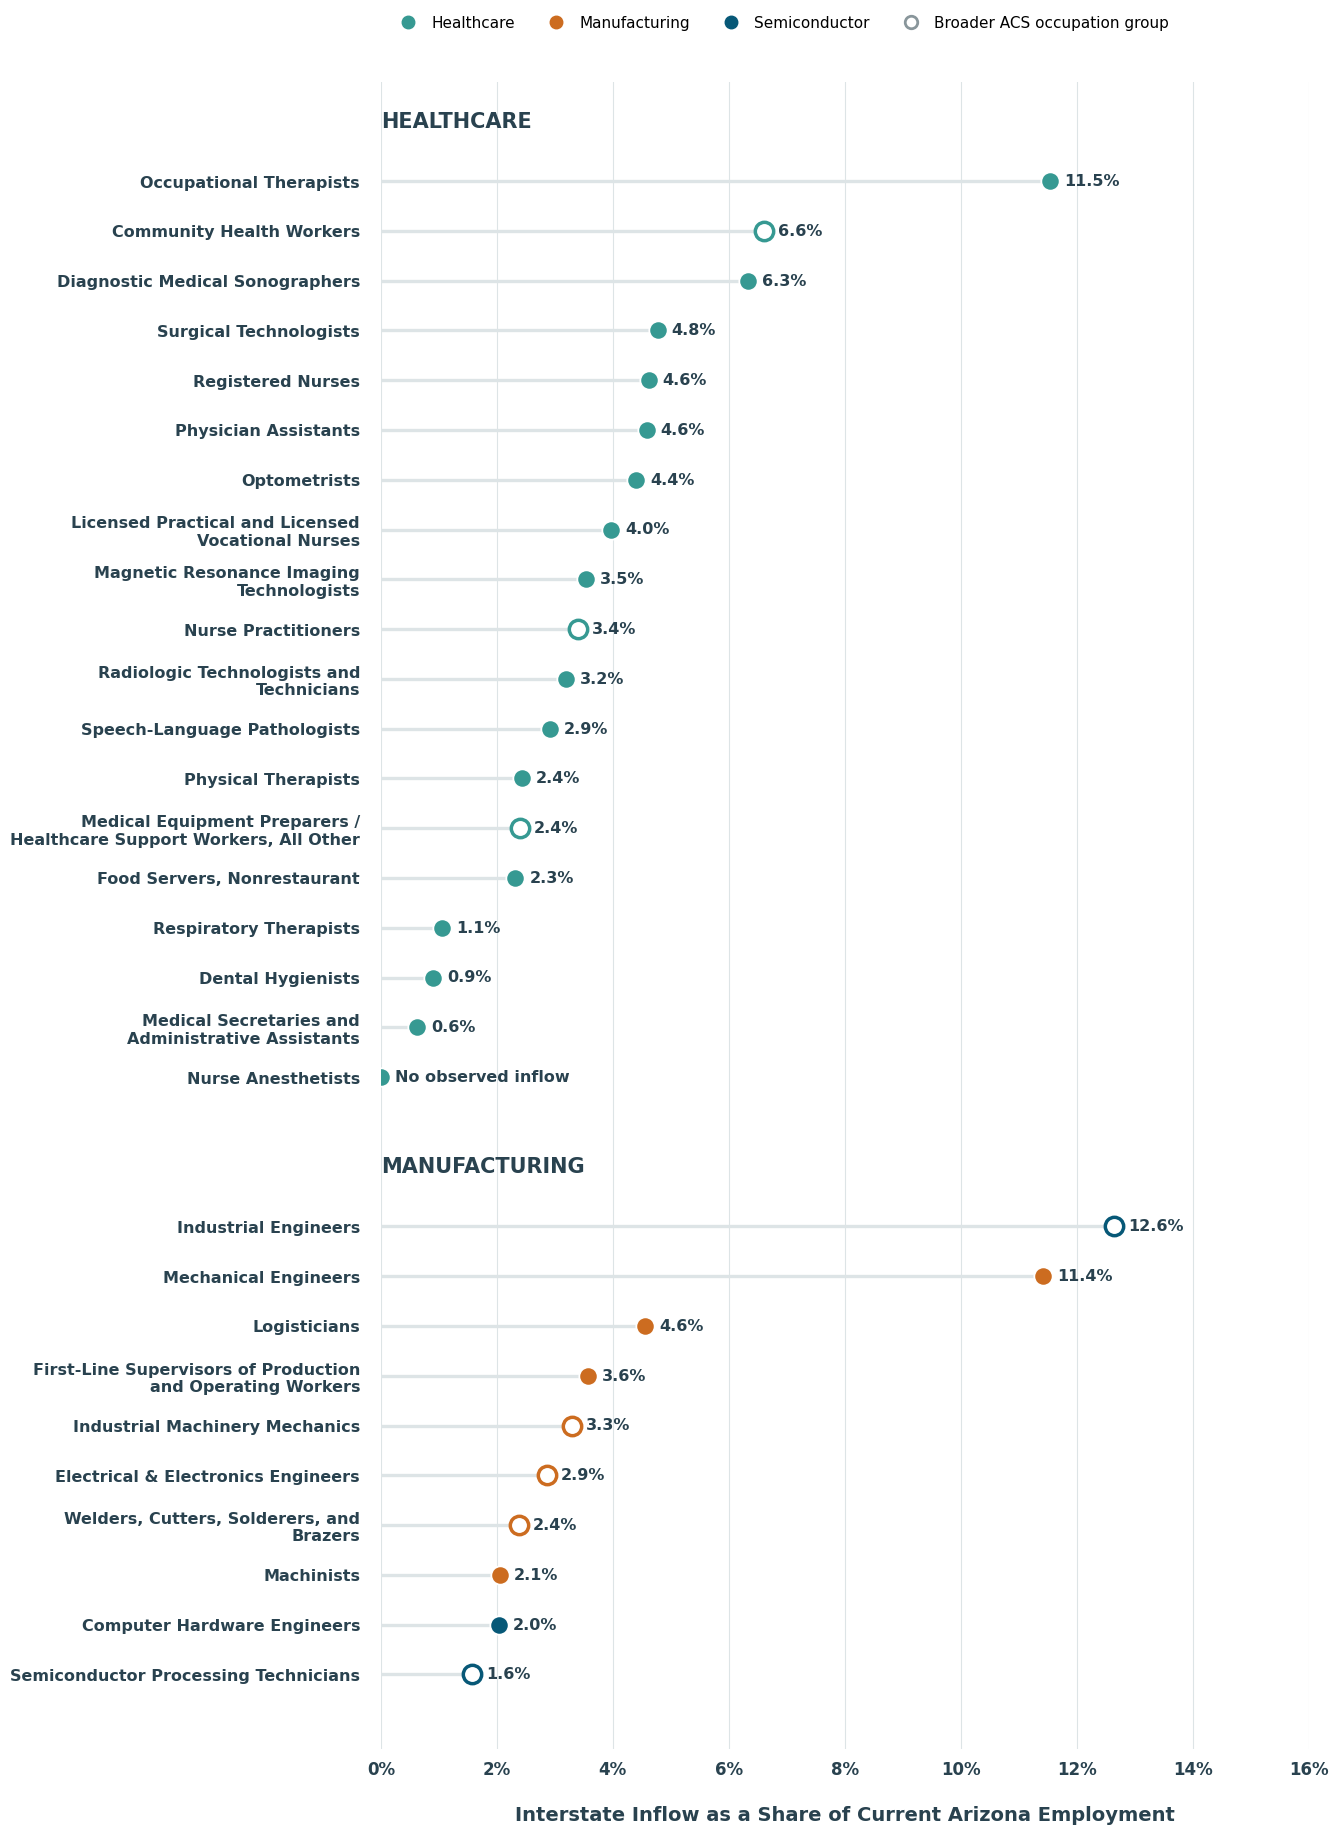


FINAL RESULTS

Original selected occupations: 36
Detailed SOCs with usable match: 31
Unique chart rows: 29
No match: 5

MATCH STATUS:
Match_Status
EXACT         21
AGGREGATED    10
NO MATCH       5
Name: count, dtype: int64

SEMICONDUCTOR:
SOC_Code                            SOC_Title ACS_OCCSOC Match_Status  inflow_pct_current_AZ  inflow_sample_n
 17-2061          Computer Hardware Engineers     172061        EXACT               2.036022                2
 17-2112                 Industrial Engineers     1721XX   AGGREGATED              12.646121                3
 51-9141 Semiconductor Processing Technicians     5191XX   AGGREGATED               1.570065               19

NO MATCH:
SOC_Code                        SOC_Title   Industry
 29-1021                Dentists, General Healthcare
 29-1215       Family Medicine Physicians Healthcare
 31-2021    Physical Therapist Assistants Healthcare
 35-2012 Cooks, Institution and Cafeteria Healthcare
 53-2012                Commercial Pilots H

In [17]:
# ============================================================
# FINAL ACS MIGRATION VISUAL USING OCCSOC
# Healthcare + Manufacturing / Semiconductor
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import re
import textwrap
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# 1. CHOOSE COMPUTER
# ============================================================

# P = Personal
# W = Work

COMPUTER = "W"


def get_base(computer):

    key = str(computer).strip().upper()

    if key in {"P", "PERSONAL", "HOME", "2"}:

        return Path(
            r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart"
        )

    elif key in {"W", "WORK", "1"}:

        return Path(
            r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
        )

    else:

        raise ValueError(
            "COMPUTER must be P/PERSONAL or W/WORK"
        )


BASE = get_base(COMPUTER)

MASTER_FILE = (
    BASE / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
)

ACS_FILE = (
    BASE / "usa_00004.csv"
)

OUTPUT_EXCEL = (
    BASE / "Arizona_Migration_OCCSOC_Final.xlsx"
)

OUTPUT_PNG = (
    BASE / "Arizona_Migration_OCCSOC_Final.png"
)


# ============================================================
# 2. CLEAN SOC CODES
# ============================================================

def clean_soc(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    value = re.sub(
        r"[^0-9A-Z]",
        "",
        value
    )

    return value


# ============================================================
# 3. LOAD 36 SELECTED OCCUPATIONS
# ============================================================

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
)

master["rating"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"],
    errors="coerce"
)

selected = master[
    master["rating"].eq(5)
    & master["Industry"].isin(
        ["Healthcare", "Manufacturing"]
    )
].copy()


selected = (
    selected[
        [
            "SOC_Code",
            "SOC_Title",
            "Industry",
            "Employment ('25)"
        ]
    ]
    .drop_duplicates(
        subset=["SOC_Code"]
    )
    .copy()
)


selected["SOC_clean"] = (
    selected["SOC_Code"]
    .apply(clean_soc)
)


# ============================================================
# 4. SEMICONDUCTOR OCCUPATIONS
# ============================================================

SEMICONDUCTOR_SOCS = {
    "172061",  # Computer Hardware Engineers
    "172112",  # Industrial Engineers
    "519141",  # Semiconductor Processing Technicians
}


selected["Visual_Sector"] = (
    selected["Industry"]
)

selected.loc[
    selected["SOC_clean"].isin(
        SEMICONDUCTOR_SOCS
    ),
    "Visual_Sector"
] = "Semiconductor"


print(
    f"Selected occupations: {len(selected)}"
)

print(
    selected["Industry"]
    .value_counts()
)


# ============================================================
# 5. READ ACS HEADER
# ============================================================

header = pd.read_csv(
    ACS_FILE,
    nrows=0
)

available = header.columns.tolist()


needed = [
    "YEAR",
    "STATEFIP",
    "EMPSTAT",
    "OCCSOC",
    "MIGPLAC1",
    "PERWT"
]


missing = [
    c for c in needed
    if c not in available
]


if missing:

    raise ValueError(
        f"""
STOP — ACS file is missing:

{missing}
"""
    )


# ============================================================
# 6. FIND EXACT + AGGREGATED OCCSOC MATCHES
# ============================================================

# First find OCCSOC values actually appearing among
# employed Arizona workers in the 2024 ACS sample.

acs_occ_counts = {}


for chunk in pd.read_csv(
    ACS_FILE,
    usecols=[
        "YEAR",
        "STATEFIP",
        "EMPSTAT",
        "OCCSOC"
    ],
    chunksize=500_000,
    low_memory=False
):

    chunk["YEAR"] = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce"
    )

    chunk["STATEFIP"] = pd.to_numeric(
        chunk["STATEFIP"],
        errors="coerce"
    )

    chunk["EMPSTAT"] = pd.to_numeric(
        chunk["EMPSTAT"],
        errors="coerce"
    )


    # Latest ACS sample only

    chunk = chunk[
        chunk["YEAR"].eq(2024)
        & chunk["STATEFIP"].eq(4)
        & chunk["EMPSTAT"].eq(1)
    ].copy()


    chunk["OCCSOC_clean"] = (
        chunk["OCCSOC"]
        .apply(clean_soc)
    )


    counts = (
        chunk["OCCSOC_clean"]
        .value_counts(
            dropna=True
        )
    )


    for code, n in counts.items():

        acs_occ_counts[code] = (
            acs_occ_counts.get(code, 0)
            + int(n)
        )


acs_codes = list(
    acs_occ_counts.keys()
)


# ============================================================
# 7. MATCH EACH SOC TO OCCSOC
# ============================================================

def find_occ_match(soc):

    if pd.isna(soc):
        return pd.Series(
            [np.nan, "NO MATCH"]
        )

    soc = str(soc)


    # --------------------------------------------------------
    # Exact match
    # --------------------------------------------------------

    if soc in acs_codes:

        return pd.Series(
            [soc, "EXACT"]
        )


    # --------------------------------------------------------
    # Aggregated OCCSOC match
    # --------------------------------------------------------

    possible = []

    for code in acs_codes:

        code = str(code)

        if "X" not in code:
            continue


        pattern = (
            "^"
            + re.escape(code)
            .replace(
                "X",
                "."
            )
            + "$"
        )


        if re.match(
            pattern,
            soc
        ):

            possible.append(
                code
            )


    if len(possible) > 0:

        # Choose most specific aggregated code:
        # the one with the fewest X characters.

        possible = sorted(
            possible,
            key=lambda x: (
                x.count("X"),
                x
            )
        )

        return pd.Series(
            [
                possible[0],
                "AGGREGATED"
            ]
        )


    return pd.Series(
        [np.nan, "NO MATCH"]
    )


selected[
    [
        "ACS_OCCSOC",
        "Match_Status"
    ]
] = selected[
    "SOC_clean"
].apply(
    find_occ_match
)


print(
    "\nMATCH STATUS:"
)

print(
    selected["Match_Status"]
    .value_counts()
)


# ============================================================
# 8. REMOVE TRUE NO-MATCH OCCUPATIONS
# ============================================================

matched = selected[
    selected["Match_Status"].ne(
        "NO MATCH"
    )
].copy()


print(
    f"\nUsable occupations: {len(matched)}"
)


# ============================================================
# 9. IDENTIFY UNIQUE ACS OCCSOC GROUPS
# ============================================================
#
# IMPORTANT:
#
# Multiple detailed SOCs can map to the SAME aggregated
# ACS OCCSOC category.
#
# We calculate the migration estimate ONCE for that ACS group.
# We do not sum or duplicate the ACS estimate.


needed_occ_codes = set(
    matched["ACS_OCCSOC"]
    .dropna()
    .astype(str)
)


print(
    f"Unique ACS occupation groups: {len(needed_occ_codes)}"
)


# ============================================================
# 10. CALCULATE MIGRATION
# ============================================================
#
# Denominator:
#
#   Currently employed Arizona workers in occupation
#
# Numerator:
#
#   Those workers whose residence one year earlier
#   was another U.S. state / DC.
#
# MIGPLAC1 codes:
#
#   001-056 = U.S. states / DC / geographic codes
#
# We exclude:
#   004 = Arizona
#   non-U.S. migration codes
#
# This is interstate inflow, not international migration.


stats = {}


for code in needed_occ_codes:

    stats[code] = {
        "current_weighted": 0.0,
        "inflow_weighted": 0.0,
        "current_n": 0,
        "inflow_n": 0
    }


for chunk in pd.read_csv(
    ACS_FILE,
    usecols=needed,
    chunksize=500_000,
    low_memory=False
):

    # --------------------------------------------------------
    # Numeric variables
    # --------------------------------------------------------

    for col in [
        "YEAR",
        "STATEFIP",
        "EMPSTAT",
        "MIGPLAC1",
        "PERWT"
    ]:

        chunk[col] = pd.to_numeric(
            chunk[col],
            errors="coerce"
        )


    # --------------------------------------------------------
    # Latest sample + employed in Arizona
    # --------------------------------------------------------

    chunk = chunk[
        chunk["YEAR"].eq(2024)
        & chunk["STATEFIP"].eq(4)
        & chunk["EMPSTAT"].eq(1)
    ].copy()


    if chunk.empty:
        continue


    # --------------------------------------------------------
    # Clean OCCSOC
    # --------------------------------------------------------

    chunk["OCCSOC_clean"] = (
        chunk["OCCSOC"]
        .apply(clean_soc)
    )


    # --------------------------------------------------------
    # Only occupations we actually need
    # --------------------------------------------------------

    chunk = chunk[
        chunk["OCCSOC_clean"].isin(
            needed_occ_codes
        )
    ].copy()


    if chunk.empty:
        continue


    # --------------------------------------------------------
    # Interstate inflow
    #
    # Person currently lives in AZ but lived in
    # another U.S. state one year earlier.
    # --------------------------------------------------------

    chunk["interstate_inflow"] = (
        chunk["MIGPLAC1"].between(
            1,
            56,
            inclusive="both"
        )
        & chunk["MIGPLAC1"].ne(4)
    )


    # --------------------------------------------------------
    # Aggregate each ACS occupation group
    # --------------------------------------------------------

    for code, group in chunk.groupby(
        "OCCSOC_clean"
    ):

        stats[code][
            "current_weighted"
        ] += group["PERWT"].sum()


        stats[code][
            "current_n"
        ] += len(group)


        inflow = group[
            group["interstate_inflow"]
        ]


        stats[code][
            "inflow_weighted"
        ] += inflow["PERWT"].sum()


        stats[code][
            "inflow_n"
        ] += len(inflow)


# ============================================================
# 11. CREATE ACS RESULTS TABLE
# ============================================================

acs_results = []


for code, s in stats.items():

    denominator = s[
        "current_weighted"
    ]

    numerator = s[
        "inflow_weighted"
    ]


    if denominator > 0:

        pct = (
            numerator
            / denominator
            * 100
        )

    else:

        pct = np.nan


    acs_results.append(
        {
            "ACS_OCCSOC": code,
            "AZ_current_employed_weighted": denominator,
            "interstate_inflow_weighted": numerator,
            "inflow_pct_current_AZ": pct,
            "AZ_current_sample_n": s[
                "current_n"
            ],
            "inflow_sample_n": s[
                "inflow_n"
            ]
        }
    )


acs_results = pd.DataFrame(
    acs_results
)


# ============================================================
# 12. MERGE BACK TO OUR OCCUPATIONS
# ============================================================

final = matched.merge(
    acs_results,
    on="ACS_OCCSOC",
    how="left"
)


# ============================================================
# 13. IMPORTANT — HANDLE SHARED AGGREGATED GROUPS
# ============================================================
#
# If multiple detailed SOCs map to the SAME ACS category,
# do NOT show that estimate multiple times.
#
# Instead create one display row for the broader ACS group.


group_sizes = (
    final.groupby(
        "ACS_OCCSOC"
    )["SOC_Code"]
    .transform("nunique")
)


final["Shared_ACS_Group"] = (
    group_sizes > 1
)


# ============================================================
# 14. BUILD DISPLAY DATA
# ============================================================

display_rows = []


for occ_code, group in final.groupby(
    "ACS_OCCSOC",
    sort=False
):

    first = group.iloc[0]


    # --------------------------------------------------------
    # ONE detailed SOC
    # --------------------------------------------------------

    if len(group) == 1:

        display_name = first[
            "SOC_Title"
        ]

        visual_sector = first[
            "Visual_Sector"
        ]

        industry = first[
            "Industry"
        ]

        soc_display = first[
            "SOC_Code"
        ]


    # --------------------------------------------------------
    # MULTIPLE detailed SOCs sharing one ACS estimate
    # --------------------------------------------------------

    else:

        titles = (
            group["SOC_Title"]
            .dropna()
            .astype(str)
            .tolist()
        )


        # Short readable combined name

        if set(
            group["SOC_clean"]
        ) == {
            "172071",
            "172072"
        }:

            display_name = (
                "Electrical & Electronics Engineers"
            )

        else:

            display_name = (
                " / ".join(titles)
            )


        # If ANY occupation in this shared group is
        # semiconductor, make it semiconductor blue.

        if (
            group["Visual_Sector"]
            .eq("Semiconductor")
            .any()
        ):

            visual_sector = (
                "Semiconductor"
            )

        else:

            visual_sector = first[
                "Industry"
            ]


        industry = first[
            "Industry"
        ]

        soc_display = (
            "; ".join(
                group["SOC_Code"]
                .astype(str)
                .unique()
            )
        )


    display_rows.append(
        {
            "ACS_OCCSOC": occ_code,
            "SOC_Code": soc_display,
            "Display_Name": display_name,
            "Industry": industry,
            "Visual_Sector": visual_sector,
            "Match_Status": (
                "AGGREGATED"
                if (
                    group[
                        "Match_Status"
                    ]
                    .eq("AGGREGATED")
                    .any()
                )
                else "EXACT"
            ),
            "AZ_current_employed_weighted":
                first[
                    "AZ_current_employed_weighted"
                ],
            "interstate_inflow_weighted":
                first[
                    "interstate_inflow_weighted"
                ],
            "inflow_pct_current_AZ":
                first[
                    "inflow_pct_current_AZ"
                ],
            "AZ_current_sample_n":
                first[
                    "AZ_current_sample_n"
                ],
            "inflow_sample_n":
                first[
                    "inflow_sample_n"
                ]
        }
    )


display = pd.DataFrame(
    display_rows
)


# ============================================================
# 15. DROP ROWS WITHOUT VALID ESTIMATE
# ============================================================

display = display[
    display[
        "inflow_pct_current_AZ"
    ].notna()
].copy()


# ============================================================
# 16. SORT
# ============================================================
#
# Healthcare first.
# Manufacturing second.
#
# Within each:
# highest migration share -> lowest.


health = (
    display[
        display["Industry"].eq(
            "Healthcare"
        )
    ]
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
    .reset_index(drop=True)
)


manufacturing = (
    display[
        display["Industry"].eq(
            "Manufacturing"
        )
    ]
    .sort_values(
        "inflow_pct_current_AZ",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 17. WRAP LABELS
# ============================================================

def wrap_label(text, width=37):

    return "\n".join(
        textwrap.wrap(
            str(text),
            width=width,
            break_long_words=False
        )
    )


health["Label"] = (
    health["Display_Name"]
    .apply(wrap_label)
)

manufacturing["Label"] = (
    manufacturing["Display_Name"]
    .apply(wrap_label)
)


# ============================================================
# 18. COLORS
# ============================================================

HEALTHCARE = "#369992"

MANUFACTURING = "#CC6C20"

SEMICONDUCTOR = "#075877"

TEXT = "#29424F"

GRID = "#DDE4E6"

GRAY = "#89969B"

WHITE = "#FFFFFF"


COLORS = {
    "Healthcare": HEALTHCARE,
    "Manufacturing": MANUFACTURING,
    "Semiconductor": SEMICONDUCTOR
}


# ============================================================
# 19. CREATE ONE CONTINUOUS TOP-TO-BOTTOM LIST
# ============================================================

chart_rows = []

y = 0


# ------------------------------------------------------------
# Healthcare header
# ------------------------------------------------------------

health_header_y = y

y += 1.2


for _, row in health.iterrows():

    r = row.to_dict()

    r["y"] = y

    chart_rows.append(r)

    y += 1


# Gap between sectors

y += 0.8


# ------------------------------------------------------------
# Manufacturing header
# ------------------------------------------------------------

manufacturing_header_y = y

y += 1.2


for _, row in manufacturing.iterrows():

    r = row.to_dict()

    r["y"] = y

    chart_rows.append(r)

    y += 1


chart = pd.DataFrame(
    chart_rows
)


# ============================================================
# 20. FIGURE SIZE
# ============================================================

FIG_HEIGHT = max(
    12,
    len(chart) * 0.55 + 3
)


fig, ax = plt.subplots(
    figsize=(16, FIG_HEIGHT)
)

fig.patch.set_facecolor(
    WHITE
)

ax.set_facecolor(
    WHITE
)


# ============================================================
# 21. X RANGE
# ============================================================

max_value = chart[
    "inflow_pct_current_AZ"
].max()


XMAX = max(
    6,
    np.ceil(
        (max_value + 1.5) / 2
    ) * 2
)


ax.set_xlim(
    0,
    XMAX
)


# ============================================================
# 22. DRAW LOLLIPOPS
# ============================================================

for _, row in chart.iterrows():

    value = row[
        "inflow_pct_current_AZ"
    ]

    color = COLORS[
        row["Visual_Sector"]
    ]


    # --------------------------------------------------------
    # Connector
    # --------------------------------------------------------

    ax.hlines(
        y=row["y"],
        xmin=0,
        xmax=value,
        color=GRID,
        linewidth=2.4,
        zorder=1
    )


    # --------------------------------------------------------
    # Marker
    #
    # Exact = filled
    # Aggregated = hollow
    # --------------------------------------------------------

    if row[
        "Match_Status"
    ] == "EXACT":

        ax.scatter(
            value,
            row["y"],
            s=175,
            facecolor=color,
            edgecolor=WHITE,
            linewidth=1.3,
            zorder=3
        )

    else:

        ax.scatter(
            value,
            row["y"],
            s=175,
            facecolor=WHITE,
            edgecolor=color,
            linewidth=2.5,
            zorder=3
        )


    # --------------------------------------------------------
    # Value
    # --------------------------------------------------------

    if (
        row["inflow_sample_n"] == 0
    ):

        value_label = (
            "No observed inflow"
        )

    else:

        value_label = (
            f"{value:.1f}%"
        )


    ax.annotate(
        value_label,
        xy=(
            value,
            row["y"]
        ),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11.5,
        fontweight="bold",
        color=TEXT
    )


# ============================================================
# 23. OCCUPATION LABELS
# ============================================================

ax.set_yticks(
    chart["y"]
)

ax.set_yticklabels(
    chart["Label"],
    fontsize=11.5,
    fontweight="bold",
    color=TEXT
)


ax.tick_params(
    axis="y",
    length=0,
    pad=15
)


# ============================================================
# 24. SECTION HEADERS
# ============================================================

ax.text(
    0,
    health_header_y,
    "HEALTHCARE",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)


ax.text(
    0,
    manufacturing_header_y,
    "MANUFACTURING",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center"
)


# ============================================================
# 25. TOP -> BOTTOM
# ============================================================

ax.set_ylim(
    y + 0.5,
    -0.8
)


# ============================================================
# 26. X AXIS
# ============================================================

ax.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=0
    )
)


ax.tick_params(
    axis="x",
    labelsize=12,
    length=0,
    pad=8,
    colors=TEXT
)


for label in ax.get_xticklabels():

    label.set_fontweight(
        "bold"
    )


ax.set_xlabel(
    "Interstate Inflow as a Share of Current Arizona Employment",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=20
)


# ============================================================
# 27. GRID
# ============================================================

ax.grid(
    axis="x",
    color=GRID,
    linewidth=0.8
)

ax.grid(
    axis="y",
    visible=False
)


for spine in ax.spines.values():

    spine.set_visible(
        False
    )


# ============================================================
# 28. LEGEND
# ============================================================

legend_items = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=HEALTHCARE,
        markeredgecolor=HEALTHCARE,
        markersize=9,
        label="Healthcare"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=MANUFACTURING,
        markeredgecolor=MANUFACTURING,
        markersize=9,
        label="Manufacturing"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=SEMICONDUCTOR,
        markeredgecolor=SEMICONDUCTOR,
        markersize=9,
        label="Semiconductor"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=WHITE,
        markeredgecolor=GRAY,
        markeredgewidth=2,
        markersize=9,
        label="Broader ACS occupation group"
    )
]


fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(
        0.60,
        0.992
    ),
    frameon=False,
    ncol=4,
    fontsize=11,
    columnspacing=1.7,
    handletextpad=0.5
)


# ============================================================
# 29. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.35,
    right=0.93,
    top=0.95,
    bottom=0.07
)


# ============================================================
# 30. SAVE FIGURE
# ============================================================

plt.savefig(
    OUTPUT_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor=WHITE
)

plt.show()


# ============================================================
# 31. SAVE DATA + QA
# ============================================================

no_match = selected[
    selected[
        "Match_Status"
    ].eq("NO MATCH")
].copy()


with pd.ExcelWriter(
    OUTPUT_EXCEL,
    engine="openpyxl"
) as writer:

    final.to_excel(
        writer,
        sheet_name="Detailed_SOC",
        index=False
    )

    display.to_excel(
        writer,
        sheet_name="Chart_Data",
        index=False
    )

    no_match.to_excel(
        writer,
        sheet_name="No_Match",
        index=False
    )

    selected.to_excel(
        writer,
        sheet_name="SOC_OCCSOC_Mapping",
        index=False
    )


# ============================================================
# 32. QA PRINT
# ============================================================

print(
    "\n============================================"
)

print(
    "FINAL RESULTS"
)

print(
    "============================================"
)


print(
    f"\nOriginal selected occupations: {len(selected)}"
)

print(
    f"Detailed SOCs with usable match: {len(final)}"
)

print(
    f"Unique chart rows: {len(display)}"
)

print(
    f"No match: {len(no_match)}"
)


print(
    "\nMATCH STATUS:"
)

print(
    selected[
        "Match_Status"
    ].value_counts()
)


print(
    "\nSEMICONDUCTOR:"
)

print(
    final.loc[
        final[
            "Visual_Sector"
        ].eq(
            "Semiconductor"
        ),
        [
            "SOC_Code",
            "SOC_Title",
            "ACS_OCCSOC",
            "Match_Status",
            "inflow_pct_current_AZ",
            "inflow_sample_n"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nNO MATCH:"
)

print(
    no_match[
        [
            "SOC_Code",
            "SOC_Title",
            "Industry"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nSaved figure:"
)

print(
    OUTPUT_PNG
)

print(
    "\nSaved workbook:"
)

print(
    OUTPUT_EXCEL
)

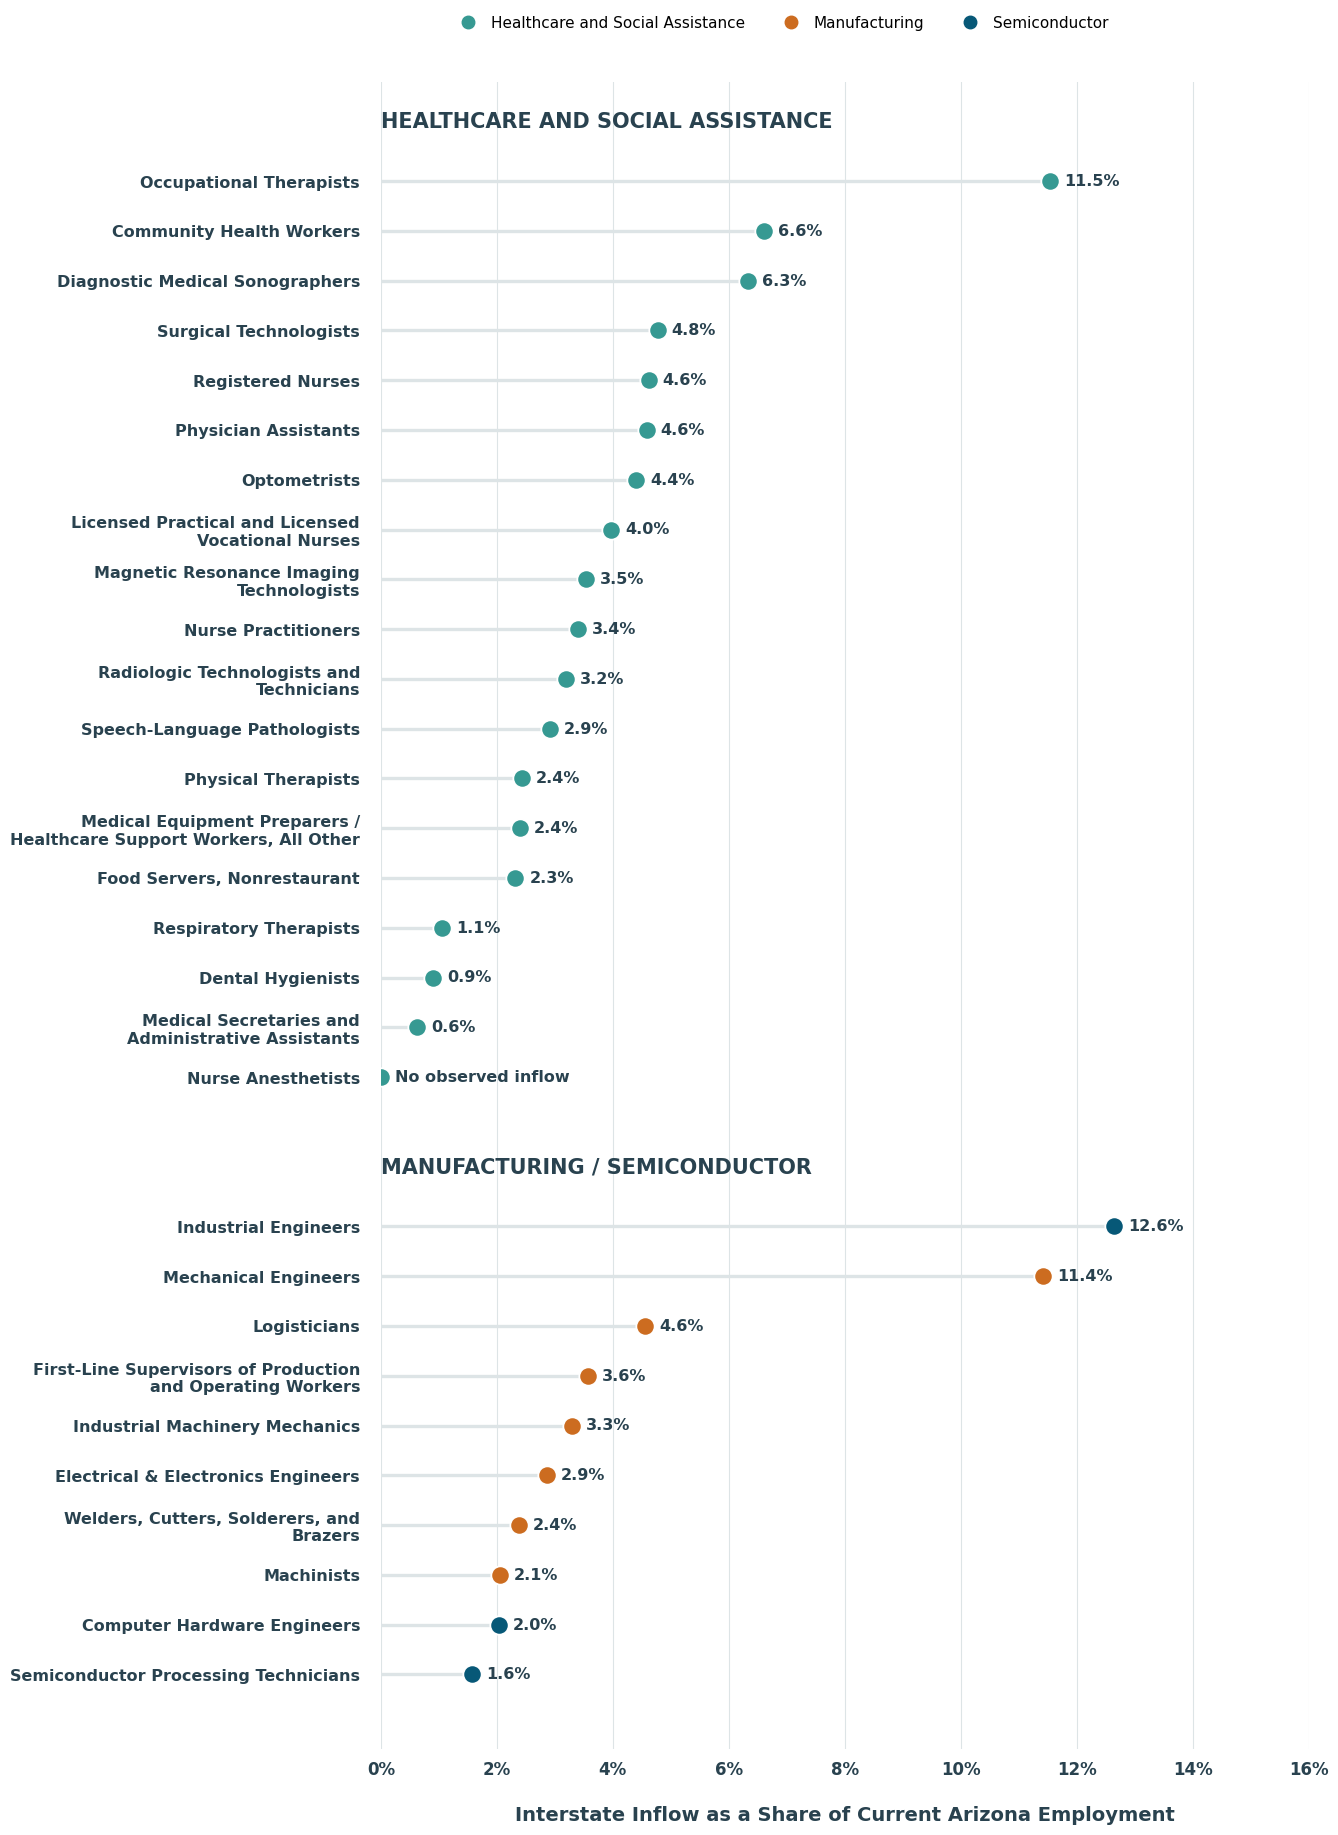

In [23]:
# ============================================================
# FINAL ACS MIGRATION VISUAL USING OCCSOC
# Healthcare and Social Assistance + Manufacturing / Semiconductor
# ============================================================

import re
import textwrap
import warnings
from pathlib import Path
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# 1. PATH CONFIGURATION
# ============================================================
COMPUTER = "W"  # "P" for Personal, "W" for Work


def get_base(computer):
    key = str(computer).strip().upper()
    if key in {"P", "PERSONAL", "HOME", "2"}:
        return Path(r"C:\Users\Arielle\Desktop\Desktop\New folder\Walmart")
    elif key in {"W", "WORK", "1"}:
        return Path(r"C:\Users\301533\Documents\Walmart\IPEDS\Files")
    else:
        raise ValueError("COMPUTER must be P/PERSONAL or W/WORK")


BASE = get_base(COMPUTER)

MASTER_FILE = BASE / "Master_CIP_SOC_Matched_Output_2 (3).xlsx"
ACS_FILE = BASE / "usa_00004.csv"
OUTPUT_EXCEL = BASE / "Arizona_Migration_OCCSOC_Final.xlsx"
OUTPUT_PNG = BASE / "Arizona_Migration_OCCSOC_Final.png"


def clean_soc(value):
    if pd.isna(value):
        return np.nan
    return re.sub(r"[^0-9A-Z]", "", str(value).strip().upper())


# ============================================================
# 2. LOAD & PREPARE DATA
# ============================================================
master = pd.read_excel(MASTER_FILE, sheet_name="Master_Matched_Data")
master["rating"] = pd.to_numeric(
    master["Sum of Occupation Rating by Ed Lvl1"], errors="coerce"
)

selected = master[
    master["rating"].eq(5) & master["Industry"].isin(["Healthcare", "Manufacturing"])
].copy()

selected = selected[["SOC_Code", "SOC_Title", "Industry"]].drop_duplicates(
    subset=["SOC_Code"]
)
selected["SOC_clean"] = selected["SOC_Code"].apply(clean_soc)

# Semiconductor SOCs
SEMICONDUCTOR_SOCS = {"172061", "172112", "519141"}

selected["Visual_Sector"] = selected["Industry"]
selected.loc[
    selected["SOC_clean"].isin(SEMICONDUCTOR_SOCS), "Visual_Sector"
] = "Semiconductor"

# Relabel Industry for Display
selected["Industry_Display"] = selected["Industry"].replace(
    {"Healthcare": "Healthcare and Social Assistance"}
)

# ============================================================
# 3. MATCH OCCSOC CODES
# ============================================================
acs_occ_counts = {}
for chunk in pd.read_csv(
    ACS_FILE,
    usecols=["YEAR", "STATEFIP", "EMPSTAT", "OCCSOC"],
    chunksize=500_000,
    low_memory=False,
):
    chunk = chunk[
        pd.to_numeric(chunk["YEAR"], errors="coerce").eq(2024)
        & pd.to_numeric(chunk["STATEFIP"], errors="coerce").eq(4)
        & pd.to_numeric(chunk["EMPSTAT"], errors="coerce").eq(1)
    ].copy()

    chunk["OCCSOC_clean"] = chunk["OCCSOC"].apply(clean_soc)
    counts = chunk["OCCSOC_clean"].value_counts(dropna=True)
    for code, n in counts.items():
        acs_occ_counts[code] = acs_occ_counts.get(code, 0) + int(n)

acs_codes = list(acs_occ_counts.keys())


def find_occ_match(soc):
    if pd.isna(soc):
        return pd.Series([np.nan, "NO MATCH"])
    soc = str(soc)
    if soc in acs_codes:
        return pd.Series([soc, "EXACT"])
    possible = []
    for code in acs_codes:
        code = str(code)
        if "X" not in code:
            continue
        pattern = "^" + re.escape(code).replace("X", ".") + "$"
        if re.match(pattern, soc):
            possible.append(code)
    if len(possible) > 0:
        possible = sorted(possible, key=lambda x: (x.count("X"), x))
        return pd.Series([possible[0], "AGGREGATED"])
    return pd.Series([np.nan, "NO MATCH"])


selected[["ACS_OCCSOC", "Match_Status"]] = selected["SOC_clean"].apply(
    find_occ_match
)
matched = selected[selected["Match_Status"].ne("NO MATCH")].copy()

needed_occ_codes = set(matched["ACS_OCCSOC"].dropna().astype(str))

stats = {
    code: {
        "current_weighted": 0.0,
        "inflow_weighted": 0.0,
        "current_n": 0,
        "inflow_n": 0,
    }
    for code in needed_occ_codes
}

for chunk in pd.read_csv(
    ACS_FILE,
    usecols=["YEAR", "STATEFIP", "EMPSTAT", "OCCSOC", "MIGPLAC1", "PERWT"],
    chunksize=500_000,
    low_memory=False,
):
    for col in ["YEAR", "STATEFIP", "EMPSTAT", "MIGPLAC1", "PERWT"]:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

    chunk = chunk[
        chunk["YEAR"].eq(2024)
        & chunk["STATEFIP"].eq(4)
        & chunk["EMPSTAT"].eq(1)
    ].copy()

    if chunk.empty:
        continue

    chunk["OCCSOC_clean"] = chunk["OCCSOC"].apply(clean_soc)
    chunk = chunk[chunk["OCCSOC_clean"].isin(needed_occ_codes)].copy()

    if chunk.empty:
        continue

    chunk["interstate_inflow"] = chunk["MIGPLAC1"].between(
        1, 56, inclusive="both"
    ) & chunk["MIGPLAC1"].ne(4)

    for code, group in chunk.groupby("OCCSOC_clean"):
        stats[code]["current_weighted"] += group["PERWT"].sum()
        stats[code]["current_n"] += len(group)
        inflow = group[group["interstate_inflow"]]
        stats[code]["inflow_weighted"] += inflow["PERWT"].sum()
        stats[code]["inflow_n"] += len(inflow)

acs_results = []
for code, s in stats.items():
    denom = s["current_weighted"]
    num = s["inflow_weighted"]
    pct = (num / denom * 100) if denom > 0 else np.nan
    acs_results.append({
        "ACS_OCCSOC": code,
        "AZ_current_employed_weighted": denom,
        "interstate_inflow_weighted": num,
        "inflow_pct_current_AZ": pct,
        "AZ_current_sample_n": s["current_n"],
        "inflow_sample_n": s["inflow_n"],
    })

acs_results = pd.DataFrame(acs_results)
final = matched.merge(acs_results, on="ACS_OCCSOC", how="left")

display_rows = []
for occ_code, group in final.groupby("ACS_OCCSOC", sort=False):
    first = group.iloc[0]
    if len(group) == 1:
        display_name = first["SOC_Title"]
        visual_sector = first["Visual_Sector"]
        industry_disp = first["Industry_Display"]
        soc_display = first["SOC_Code"]
    else:
        titles = group["SOC_Title"].dropna().astype(str).tolist()
        if set(group["SOC_clean"]) == {"172071", "172072"}:
            display_name = "Electrical & Electronics Engineers"
        else:
            display_name = " / ".join(titles)

        if group["Visual_Sector"].eq("Semiconductor").any():
            visual_sector = "Semiconductor"
        else:
            visual_sector = first["Industry_Display"]

        industry_disp = first["Industry_Display"]
        soc_display = "; ".join(group["SOC_Code"].astype(str).unique())

    display_rows.append({
        "ACS_OCCSOC": occ_code,
        "SOC_Code": soc_display,
        "Display_Name": display_name,
        "Industry_Display": industry_disp,
        "Visual_Sector": visual_sector,
        "inflow_pct_current_AZ": first["inflow_pct_current_AZ"],
        "inflow_sample_n": first["inflow_sample_n"],
    })

display = pd.DataFrame(display_rows)
display = display[display["inflow_pct_current_AZ"].notna()].copy()

health = (
    display[
        display["Industry_Display"].eq("Healthcare and Social Assistance")
    ]
    .sort_values("inflow_pct_current_AZ", ascending=False)
    .reset_index(drop=True)
)

manufacturing = (
    display[display["Industry_Display"].eq("Manufacturing")]
    .sort_values("inflow_pct_current_AZ", ascending=False)
    .reset_index(drop=True)
)


def wrap_label(text, width=37):
    return "\n".join(
        textwrap.wrap(str(text), width=width, break_long_words=False)
    )


health["Label"] = health["Display_Name"].apply(wrap_label)
manufacturing["Label"] = manufacturing["Display_Name"].apply(wrap_label)

# ============================================================
# 4. PLOTTING VISUAL
# ============================================================
HEALTHCARE = "#369992"
MANUFACTURING = "#CC6C20"
SEMICONDUCTOR = "#075877"
TEXT = "#29424F"
GRID = "#DDE4E6"
WHITE = "#FFFFFF"

COLORS = {
    "Healthcare and Social Assistance": HEALTHCARE,
    "Healthcare": HEALTHCARE,
    "Manufacturing": MANUFACTURING,
    "Semiconductor": SEMICONDUCTOR,
}

chart_rows = []
y = 0

health_header_y = y
y += 1.2

for _, row in health.iterrows():
    r = row.to_dict()
    r["y"] = y
    chart_rows.append(r)
    y += 1

y += 0.8

manufacturing_header_y = y
y += 1.2

for _, row in manufacturing.iterrows():
    r = row.to_dict()
    r["y"] = y
    chart_rows.append(r)
    y += 1

chart = pd.DataFrame(chart_rows)

FIG_HEIGHT = max(12, len(chart) * 0.55 + 3)
fig, ax = plt.subplots(figsize=(16, FIG_HEIGHT))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

max_value = chart["inflow_pct_current_AZ"].max()
XMAX = max(6, np.ceil((max_value + 1.5) / 2) * 2)
ax.set_xlim(0, XMAX)

for _, row in chart.iterrows():
    value = row["inflow_pct_current_AZ"]
    color = COLORS[row["Visual_Sector"]]

    ax.hlines(
        y=row["y"], xmin=0, xmax=value, color=GRID, linewidth=2.4, zorder=1
    )

    ax.scatter(
        value,
        row["y"],
        s=175,
        facecolor=color,
        edgecolor=WHITE,
        linewidth=1.3,
        zorder=3,
    )

    value_label = (
        "No observed inflow" if row["inflow_sample_n"] == 0 else f"{value:.1f}%"
    )

    ax.annotate(
        value_label,
        xy=(value, row["y"]),
        xytext=(10, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11.5,
        fontweight="bold",
        color=TEXT,
    )

ax.set_yticks(chart["y"])
ax.set_yticklabels(
    chart["Label"], fontsize=11.5, fontweight="bold", color=TEXT
)
ax.tick_params(axis="y", length=0, pad=15)

# Healthcare Section Header
ax.text(
    0,
    health_header_y,
    "HEALTHCARE AND SOCIAL ASSISTANCE",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center",
)

# Manufacturing / Semiconductor Section Header
ax.text(
    0,
    manufacturing_header_y,
    "MANUFACTURING / SEMICONDUCTOR",
    fontsize=15,
    fontweight="bold",
    color=TEXT,
    ha="left",
    va="center",
)

ax.set_ylim(y + 0.5, -0.8)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="x", labelsize=12, length=0, pad=8, colors=TEXT)
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

ax.set_xlabel(
    "Interstate Inflow as a Share of Current Arizona Employment",
    fontsize=14,
    fontweight="bold",
    color=TEXT,
    labelpad=20,
)

ax.grid(axis="x", color=GRID, linewidth=0.8)
ax.grid(axis="y", visible=False)

for spine in ax.spines.values():
    spine.set_visible(False)

# Legend Setup
legend_items = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=HEALTHCARE,
        markeredgecolor=HEALTHCARE,
        markersize=9,
        label="Healthcare and Social Assistance",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=MANUFACTURING,
        markeredgecolor=MANUFACTURING,
        markersize=9,
        label="Manufacturing",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=SEMICONDUCTOR,
        markeredgecolor=SEMICONDUCTOR,
        markersize=9,
        label="Semiconductor",
    ),
]

fig.legend(
    handles=legend_items,
    loc="upper center",
    bbox_to_anchor=(0.60, 0.992),
    frameon=False,
    ncol=3,
    fontsize=11,
    columnspacing=2.0,
    handletextpad=0.5,
)

plt.subplots_adjust(left=0.35, right=0.93, top=0.95, bottom=0.07)

plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor=WHITE)
plt.show()